# Google Colab & Google Drive

In [ ]:
!nvidia-smi

Thu Apr 23 04:21:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

In [ ]:
!pwd
%cd /content/drive/MyDrive/nectec
!pwd

In [ ]:
!nvidia-smi

# CNN for MNIST dataset

In [ ]:
import torch
import torchvision

In [ ]:
batch_size_train = 64
batch_size_test = 1000

train_dataset = torchvision.datasets.MNIST(
    '/files/', train=True, download=True,
    transform=torchvision.transforms.Compose([
        # torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(
            (0.1307,), (0.3081,))
    ]))
train_loader = torch.utils.data.DataLoader(
  train_dataset,
  batch_size=batch_size_train, shuffle=True)

test_dataset = torchvision.datasets.MNIST(
    '/files/', train=False, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(
            (0.1307,), (0.3081,))
    ]))
test_loader = torch.utils.data.DataLoader(
  test_dataset,
  batch_size=batch_size_test, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 533kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.03MB/s]


In [ ]:
!ls /files/MNIST/raw

t10k-images-idx3-ubyte	   train-images-idx3-ubyte
t10k-images-idx3-ubyte.gz  train-images-idx3-ubyte.gz
t10k-labels-idx1-ubyte	   train-labels-idx1-ubyte
t10k-labels-idx1-ubyte.gz  train-labels-idx1-ubyte.gz


In [ ]:
(example_data, example_targets) = test_dataset[3]

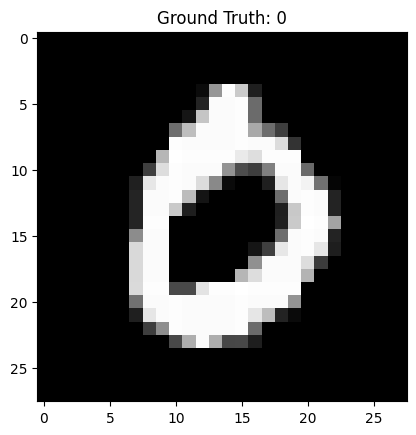

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(example_data[0],interpolation='none', cmap="gray")
plt.title("Ground Truth: {}".format(example_targets))
plt.show()

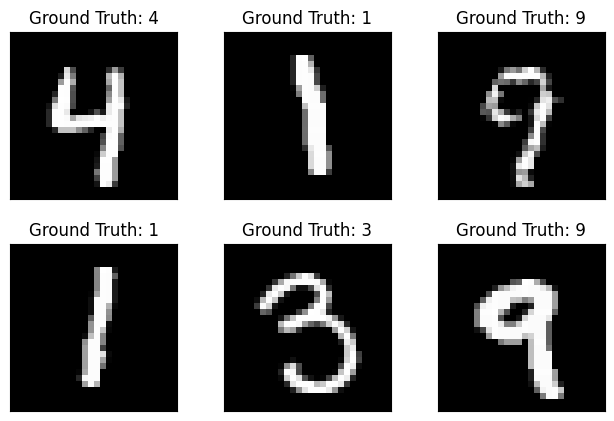

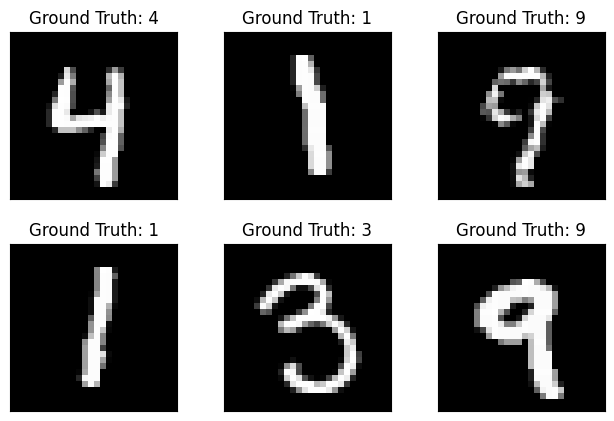

In [ ]:
import matplotlib.pyplot as plt

examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)


fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
fig

## Building Neural Network

In [ ]:
!nvidia-smi

Thu Apr 23 04:26:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
device = "cuda"

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv11 = nn.Conv2d(1, 8, kernel_size=3, padding=1)  # input 1 channel, 8 filters = output 8 channels, output same size as input
        self.bn11   = nn.BatchNorm2d(8)
        self.conv12 = nn.Conv2d(8, 8, kernel_size=3, padding=1)
        self.bn12   = nn.BatchNorm2d(8)
        self.conv13 = nn.Conv2d(8, 8, kernel_size=3, padding=1)
        self.bn13   = nn.BatchNorm2d(8)

        self.conv21 = nn.Conv2d(8, 10, kernel_size=3, padding=1)
        self.conv22 = nn.Conv2d(10, 10, kernel_size=3, padding=1)
        self.conv23 = nn.Conv2d(10, 10, kernel_size=3, padding=1)

        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(490, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x0):
        # reduce size from 28x28 to 14x14 >> (batch_size, 8, 14, 14)
        x1 = F.relu(self.bn11(self.conv11(x0)))

        x = F.relu(self.bn12(self.conv12(x1)))
        x = F.relu(self.bn13(self.conv13(x)))

        print(x1.shape, x.shape)
        x = x + x1
        print(x.shape)
        x = F.max_pool2d(x, 2)

        # size 14x14 >> (batchsize, 10, 7, 7)
        x = F.relu(self.conv21(x))
        x = F.relu(self.conv22(x))
        x = F.relu(self.conv23(x))
        x = F.max_pool2d(x, 2)

        # "flatten" >> arrange all values on the feature maps as a single vector >> 490 values
        x = x.view(-1, x.size(dim=1)*x.size(dim=2)*x.size(dim=3))

        x = F.relu(self.fc1(x))
        # x = F.dropout(x, training=self.training) # dropout apply only during training
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [ ]:
model = CNN()

In [ ]:
x = torch.rand((8, 1, 28, 28), requires_grad=True)

y = model(x)

torch.Size([8, 8, 28, 28]) torch.Size([8, 8, 28, 28])
torch.Size([8, 8, 28, 28])


In [ ]:
y

tensor([[-2.1876, -2.2914, -2.3128, -2.1731, -2.3755, -2.1398, -2.4101, -2.5485,
         -2.4756, -2.1970],
        [-2.1880, -2.2976, -2.3262, -2.1690, -2.3714, -2.1323, -2.3909, -2.5513,
         -2.4804, -2.2050],
        [-2.1824, -2.2904, -2.3225, -2.1817, -2.3695, -2.1355, -2.3781, -2.5524,
         -2.4744, -2.2202],
        [-2.1917, -2.2763, -2.3156, -2.1967, -2.3740, -2.1394, -2.3860, -2.5401,
         -2.4812, -2.2036],
        [-2.1977, -2.2750, -2.3209, -2.1866, -2.3803, -2.1431, -2.3642, -2.5437,
         -2.4723, -2.2178],
        [-2.1931, -2.2941, -2.3294, -2.1703, -2.3734, -2.1238, -2.3879, -2.5498,
         -2.4833, -2.2077],
        [-2.1919, -2.2880, -2.3111, -2.1826, -2.3850, -2.1324, -2.3948, -2.5548,
         -2.4688, -2.2011],
        [-2.1915, -2.2953, -2.3137, -2.1691, -2.3789, -2.1339, -2.3927, -2.5584,
         -2.4567, -2.2184]], grad_fn=<LogSoftmaxBackward0>)

In [ ]:
model.eval()
model.train()

CNN(
  (conv11): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn11): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv12): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn12): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv13): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn13): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv21): Conv2d(8, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv22): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv23): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2_drop): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=490, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)

In [ ]:
# training config
n_epochs = 3
learning_rate = 0.001
momentum = 0.5
log_interval = 100

# random_seed = 1
# torch.manual_seed(random_seed)

In [ ]:
#from tqdm import tqdm
from tqdm import tqdm_notebook as tqdm

def train_epoch(model, optimizer, data_loader, device):

  model.train()
  model.to(device)
  train_loss = 0
  for batch_idx, (data, target) in enumerate(pbar := tqdm(data_loader)):
    data, target = data.to(device), target.to(device)

    optimizer.zero_grad()

    output = model(data)              # predict output for current data
    loss = F.nll_loss(output, target) # compute loss
    loss.backward()                   # backprop to get gradient

    optimizer.step()                  # update the model

    train_loss += loss

    if batch_idx % log_interval == 0:
      pbar.set_description('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
        epoch, batch_idx * len(data), len(data_loader.dataset),
        100. * batch_idx / len(data_loader), loss.item()))

  return train_loss

In [ ]:
def test(model, data_loader, device):
  model.eval()
  model.to(device)
  test_loss = 0
  correct = 0
  with torch.no_grad(): # no need for gradient >>not allocate additional variables
    for data, target in data_loader:
      data, target = data.to(device), target.to(device)
      output = model(data)
      test_loss += F.nll_loss(output, target, size_average=False).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(target.data.view_as(pred)).sum()
  test_loss /= len(data_loader.dataset)
  test_acc = 100. * correct / len(data_loader.dataset)
  return test_acc, test_loss

In [ ]:
from tqdm import trange

network = CNN()
optimizer = optim.Adam(network.parameters(), lr=1e-3)

best_acc = 0
for epoch in (pbar := trange(1, n_epochs + 1)):
  train_epoch(network, optimizer, train_loader, device)
  test_acc, test_loss = test(network, test_loader, device)
  if test_acc > best_acc:
    pbar.set_description('Test accracy improves from {:.2f} to {:.2f}'.format(best_acc, test_acc))
    best_acc = test_acc

    torch.save(network.state_dict(), 'model.pth')
    torch.save(optimizer.state_dict(), 'optimizer.pth')

  0%|          | 0/3 [00:00<?, ?it/s]/tmp/ipykernel_4299/1516037767.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for batch_idx, (data, target) in enumerate(pbar := tqdm(data_loader)):


  0%|          | 0/938 [00:00<?, ?it/s]

torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 2

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3178: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)


torch.Size([1000, 8, 28, 28]) torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28]) torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28]) torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28]) torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28]) torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28]) torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28]) torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28]) torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28])


...

torch.Size([1000, 8, 28, 28]) torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28])


  0%|          | 0/938 [00:00<?, ?it/s]

torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 28, 28]) torch.Size([64, 8, 28, 28])
torch.Size([64, 8, 2

Test accracy improves from 97.95 to 98.68: 100%|██████████| 3/3 [01:36<00:00, 32.24s/it]

torch.Size([1000, 8, 28, 28]) torch.Size([1000, 8, 28, 28])
torch.Size([1000, 8, 28, 28])


In [ ]:
network.conv11.weight.size()

# Transfer Learning with TIMM (Pytorch Image Models)

In [ ]:
!pip install timm

In [ ]:
from timm.models import create_model

In [ ]:
import timm

print(len(timm.list_models('*')))

1284


In [ ]:
import timm

for i,n in enumerate(timm.list_models('*')):
  print(i, n)

0 aimv2_1b_patch14_224
1 aimv2_1b_patch14_336
2 aimv2_1b_patch14_448
3 aimv2_3b_patch14_224
4 aimv2_3b_patch14_336
5 aimv2_3b_patch14_448
6 aimv2_huge_patch14_224
7 aimv2_huge_patch14_336
8 aimv2_huge_patch14_448
9 aimv2_large_patch14_224
10 aimv2_large_patch14_336
11 aimv2_large_patch14_448
12 bat_resnext26ts
13 beit3_base_patch16_224
14 beit3_giant_patch14_224
15 beit3_giant_patch14_336
16 beit3_large_patch16_224
17 beit_base_patch16_224
18 beit_base_patch16_384
19 beit_large_patch16_224
20 beit_large_patch16_384
21 beit_large_patch16_512
22 beitv2_base_patch16_224
23 beitv2_large_patch16_224
24 botnet26t_256
25 botnet50ts_256
26 caformer_b36
27 caformer_m36
28 caformer_s18
29 caformer_s36
30 cait_m36_384
31 cait_m48_448
32 cait_s24_224
33 cait_s24_384
34 cait_s36_384
35 cait_xs24_384
36 cait_xxs24_224
37 cait_xxs24_384
38 cait_xxs36_224
39 cait_xxs36_384
40 coat_lite_medium
41 coat_lite_medium_384
42 coat_lite_mini
43 coat_lite_small
44 coat_lite_tiny
45 coat_mini
46 coat_small
47 c

In [ ]:
for i,n in enumerate(timm.list_models('*', pretrained=True)):
  print(i,n)

0 aimv2_1b_patch14_224.apple_pt
1 aimv2_1b_patch14_336.apple_pt
2 aimv2_1b_patch14_448.apple_pt
3 aimv2_3b_patch14_224.apple_pt
4 aimv2_3b_patch14_336.apple_pt
5 aimv2_3b_patch14_448.apple_pt
6 aimv2_huge_patch14_224.apple_pt
7 aimv2_huge_patch14_336.apple_pt
8 aimv2_huge_patch14_448.apple_pt
9 aimv2_large_patch14_224.apple_pt
10 aimv2_large_patch14_224.apple_pt_dist
11 aimv2_large_patch14_336.apple_pt
12 aimv2_large_patch14_336.apple_pt_dist
13 aimv2_large_patch14_448.apple_pt
14 bat_resnext26ts.ch_in1k
15 beit3_base_patch16_224.in22k_ft_in1k
16 beit3_base_patch16_224.indomain_in22k_ft_in1k
17 beit3_base_patch16_224.indomain_pt
18 beit3_base_patch16_224.pt
19 beit3_large_patch16_224.in22k_ft_in1k
20 beit3_large_patch16_224.indomain_in22k_ft_in1k
21 beit3_large_patch16_224.indomain_pt
22 beit3_large_patch16_224.pt
23 beit_base_patch16_224.in22k_ft_in22k
24 beit_base_patch16_224.in22k_ft_in22k_in1k
25 beit_base_patch16_384.in22k_ft_in22k_in1k
26 beit_large_patch16_224.in22k_ft_in22k
27 

In [ ]:
model = timm.create_model('resnet50d', pretrained=True)

model.safetensors:   0%|          | 0.00/103M [00:00<?, ?B/s]

In [ ]:
model

In [ ]:
model.default_cfg

In [ ]:
# it's possible to adapt existing model for different input channels
# useful when we want to retrain the model on grayscale images
model = timm.create_model('resnet50d', pretrained=True, in_chans=1)

x = torch.rand((1,1,224,224)) # batch, channels, height, width

model(x).size()

In [ ]:
import timm

# custom clasification head
model = timm.create_model('resnet50d', pretrained=True, num_classes=10)
model

ResNet(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Co

In [ ]:
model.fc

Linear(in_features=2048, out_features=10, bias=True)

In [ ]:
num_in_features = model.get_classifier().in_features

model.fc = nn.Sequential(
    nn.BatchNorm1d(num_in_features),
    nn.Linear(in_features=num_in_features, out_features=512, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(in_features=512, out_features=1, bias=False)
)

model

ResNet(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Co

In [ ]:
from timm.data.transforms_factory import create_transform

create_transform(224, is_training=True)

In [ ]:
!ls /content/

In [ ]:
%cd /content/
!wget https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz

In [ ]:
!tar -xf imagenette2-320.tgz

In [ ]:
!ls imagenette2-320/train

In [ ]:
from timm.data.dataset import ImageDataset

dataset = ImageDataset('./imagenette2-320')

In [ ]:
dataset.reader.class_to_idx # NOTE: here timm 0.9.2, previous version use 'dataset.parser'

In [ ]:
idx_to_class = {dataset.reader.class_to_idx[k]:k for k in dataset.reader.class_to_idx}

In [ ]:
idx_to_class

In [ ]:
image,label = dataset[10]

plt.imshow(image)
print(label, idx_to_class[label])

In [ ]:
import torch
from timm.data.transforms_factory import create_transform

dataset = ImageDataset('./imagenette2-320',
                       transform=create_transform(224, is_training=True))

train_loader = torch.utils.data.DataLoader(
  dataset,
  batch_size=64, shuffle=True)


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
epoch = 3
log_interval = 10
device = "cuda:0"
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

train_epoch(model, optimizer, train_loader, device)

# Summary
- Important components: Dataset DatasetLoader, Transform, Device, Optimizer
- TIMM has lots of models and pretrained-models
- Load TIMM with desired number of classes or customize classification layer (fc)
- Best practice: load __pretrained-models__ and __finetune__ it on custom dataset

***

# Gradcam

In [ ]:
!ls

In [ ]:
!pip install grad-cam

In [ ]:
model = timm.create_model('resnet50d', pretrained=True)
model

In [ ]:
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

transform = create_transform(**resolve_data_config(model.pretrained_cfg, model=model))
transform

In [ ]:
!wget https://media.roboflow.com/notebooks/examples/dog.jpeg

In [ ]:
from PIL import Image

pil_img = Image.open('dog.jpeg').convert('RGB')
input_tensor = transform(pil_img)

In [ ]:
pil_img = pil_img.resize((224, 224))#, Image.ANTIALIAS)

In [ ]:
pil_img

In [ ]:
model

In [ ]:
from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
target_layers = [model.layer4[-1]]

# Construct the CAM object once, and then re-use it on many images:
cam = GradCAM(model=model, target_layers=target_layers) #, use_cuda=True)

# You can also use it within a with statement, to make sure it is freed,
# In case you need to re-create it inside an outer loop:
# with GradCAM(model=model, target_layers=target_layers, use_cuda=args.use_cuda) as cam:
#   ...

# We have to specify the target we want to generate
# the Class Activation Maps for.
# If targets is None, the highest scoring category
# will be used for every image in the batch.
# Here we use ClassifierOutputTarget, but you can define your own custom targets
# That are, for example, combinations of categories, or specific outputs in a non standard model.

targets = [ClassifierOutputTarget(153)]  # 153	Maltese dog, Maltese terrier, Maltese cf https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/

# You can also pass aug_smooth=True and eigen_smooth=True, to apply smoothing.
grayscale_cam = cam(input_tensor=input_tensor.unsqueeze(0), targets=targets)

# In this example grayscale_cam has only one image in the batch:
import numpy as np
grayscale_cam = grayscale_cam[0, :]

visualization = show_cam_on_image(np.asarray(pil_img)/255, grayscale_cam, use_rgb=True) #

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(visualization)

# Simple object detection

In [ ]:
train_dataset = torchvision.datasets.MNIST(
    '/files/', train=True, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(
            (0.1307,), (0.3081,))
    ]))

In [ ]:
def tensor_to_image(x):
  mean = 0.1307
  std = 0.3081

  return (x * std + mean)

In [ ]:
# create dataset
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt

XX = np.zeros((10000, 1, 140, 140))
YY = []

for t in range(10000): # trange(X_train.shape[0]):
    x,y = train_dataset[t]
    x = x.numpy()[0]

    XX[t, 0, :, :] = x.min() # not zero, nor -1

    ww = 14 + np.random.randint(32)
    w,h = ww+np.random.randint(5), ww+np.random.randint(5)
    xx = cv2.resize(x, dsize=(h,w), interpolation=cv2.INTER_CUBIC)
    x0,y0 = np.random.randint(140-w), np.random.randint(140-h)
    XX[t, 0, x0:x0+w, y0:y0+h] = xx
    print(x0, y0, w, h)

    cx, cy = x0+w//2, y0+h//2
    p = torch.tensor([cx/140., cy/140., w/140., h/140.])
    yy = F.one_hot(torch.tensor(y), num_classes=10)
    yy = torch.concat((p, yy), dim=0)
    YY.append(yy)

    # O = tensor_to_image(XX[t,0]).copy() * 255
    # print(O.min(), O.max())
    # cv2.rectangle(O, (y0, x0), (y0+h, x0+w), 127, 2)
    # plt.imshow(O, cmap="gray")
    # plt.show()
    # break

Streaming output truncated to the last 5000 lines.
34 26 36 34
4 74 37 35
30 18 21 22
50 40 46 46
1 78 22 20
68 51 40 38
67 87 29 27
7 72 38 38
92 80 40 39
29 56 30 31
56 76 30 29
76 40 42 46
26 27 20 23
93 47 29 29
67 90 20 21
86 65 27 28
37 19 39 39
15 107 31 31
45 15 43 41
102 113 18 18
5 10 47 45
59 28 34 37
22 87 47 45
23 0 29 26
73 105 22 22
4 18 39 36
50 108 22 20
49 5 40 37
10 19 42 41
89 53 30 31
9 55 36 40
71 89 33 32
0 13 34 32
90 56 22 19
45 89 23 21
87 55 23 21
18 94 40 38
36 54 30 33
88 23 33 29
87 22 36 35
98 88 40 38
49 1 45 46
63 43 43 42
18 18 41 40
26 87 26 23
50 67 44 45
70 17 31 31
53 74 36 39
89 89 16 20
48 80 18 16
73 78 40 41
14 120 17 16
80 95 43 41
98 42 35 32
95 102 32 34
5 42 25 24
7 6 34 30
82 40 48 46
91 53 29 29
20 72 29 30
60 34 41 44
63 89 42 41
35 114 17 18
92 20 20 21
80 111 25 25
58 42 33 32
28 50 30 31
90 84 47 46
88 21 20 19
42 92 35 38
42 88 30 30
70 35 47 48
96 21 30 29
49 35 46 44
73 29 47 44
99 37 25 21
3 91 40 39
27 81 44 45
23 83 38 38
76 61 

In [ ]:
XX.min(), XX.max()

(np.float64(-1.248997688293457), np.float64(3.761190891265869))

In [ ]:
XX = torch.tensor(XX)

In [ ]:
XX.shape

torch.Size([10000, 1, 140, 140])

In [ ]:
YY = torch.stack(YY)
YY.shape

torch.Size([10000, 14])

In [ ]:
XX = XX.to(torch.float32)

In [ ]:
YY[1]

tensor([0.6143, 0.5429, 0.2357, 0.2071, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000])

tensor(-0.8454) tensor(3.2757)
-33.09289 290.68518
tensor(107.0000) tensor(86.) tensor(44.) tensor(47.)


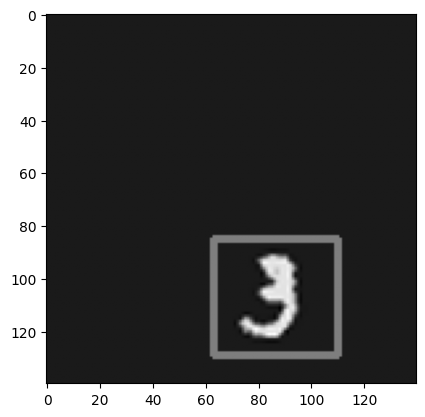

In [ ]:
idx = 10

print(XX[idx,0].min(), XX[idx,0].max())

OO = tensor_to_image(XX[idx,0]).numpy().copy() * 255
cx,cy,w,h = YY[idx,:4] * 140

print(OO.min(), OO.max())
print(cx, cy, w, h)

x0 = cx-w//2
y0 = cy-h//2
x1 = x0 + w
y1 = y0 + h

cv2.rectangle(OO, (int(y0), int(x0)), (int(y1), int(x1)), 127, 2)

plt.imshow(OO, cmap="gray")

In [ ]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=11, padding=5, stride=5) # -> 28
        self.conv2 = nn.Conv2d(16, 16, kernel_size=3, padding=1, stride=2)  # -> 14
        self.conv3 = nn.Conv2d(16, 16, kernel_size=3, padding=1, stride=2) # -> 7
        self.conv4 = nn.Conv2d(16, 16, kernel_size=3, padding=1) # -> 7

        self.bn1 = nn.BatchNorm2d(16)
        self.bn2 = nn.BatchNorm2d(16)
        self.bn3 = nn.BatchNorm2d(16)
        self.bn4 = nn.BatchNorm2d(16)

        self.fc = nn.Linear(7*7*16, 14)

    def forward(self, x, y=None): # [B, 1, 140, 140]
        x = F.relu(self.bn1(self.conv1(x))) # -> 28
        x = F.relu(self.bn2(self.conv2(x))) # -> 14
        x = F.relu(self.bn3(self.conv3(x))) # -> 7
        x = F.relu(self.bn4(self.conv4(x))) # -> 7
        x = self.fc(x.view(-1, 7*7*16)) # !!!

        pos = x[:, :4]
        cls = x[:, 4:]

        loss = None
        if y is not None:
          pos_loss = F.mse_loss(torch.sigmoid(pos), y[:, :4])
          cls_loss = F.cross_entropy(cls, y[:, 4:])
          loss = pos_loss + cls_loss

        return {
            "x": x,
            "loss": loss,
            "pos": pos,
            "cls": cls
        }

In [ ]:
model = CNN()

o = model(XX[:1], YY[:1])
o["x"].shape

torch.Size([1, 14])

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(XX, YY)

batch_size = 8
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
#from tqdm import tqdm
from tqdm import tqdm_notebook as tqdm

def train_epoch(epoch, model, optimizer, data_loader, device):

  model.train()
  model.to(device)
  train_loss = 0
  for batch_idx, (data, target) in enumerate(pbar := tqdm(data_loader)):
    data, target = data.to(device), target.to(device)

    optimizer.zero_grad()

    output = model(data, target)                # predict output for current data
    output["loss"].backward()                   # backprop to get gradient

    optimizer.step()                  # update the model

    closs = output["loss"].item()
    train_loss += closs

    if batch_idx % 5 == 0:
      pbar.set_description('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
        epoch, batch_idx * len(data), len(data_loader.dataset),
        100. * batch_idx / len(data_loader), closs))

  return train_loss

In [ ]:
from tqdm import trange
import torch.optim as optim

network = CNN()
optimizer = optim.Adam(network.parameters(), lr=1e-3)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

n_epochs = 30
best_acc = 0
for epoch in (pbar := trange(1, n_epochs + 1)):
  train_epoch(epoch, network, optimizer, dataloader, device)

cuda:0


  0%|          | 0/30 [00:00<?, ?it/s]/tmp/ipykernel_4299/3287001752.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for batch_idx, (data, target) in enumerate(pbar := tqdm(data_loader)):


  0%|          | 0/1250 [00:00<?, ?it/s]

  3%|▎         | 1/30 [00:06<03:17,  6.82s/it]

  0%|          | 0/1250 [00:00<?, ?it/s]

...

 93%|█████████▎| 28/30 [03:12<00:13,  6.58s/it]

  0%|          | 0/1250 [00:00<?, ?it/s]

 97%|█████████▋| 29/30 [03:19<00:06,  6.64s/it]

  0%|          | 0/1250 [00:00<?, ?it/s]

100%|██████████| 30/30 [03:25<00:00,  6.85s/it]


55 78 81 80 tensor(0) tensor(4)
58 82 36 36
*****


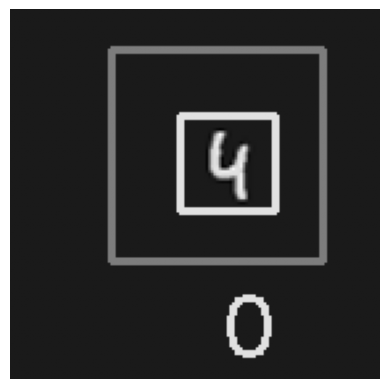

70 51 51 18 tensor(5) tensor(9)
118 69 35 38
*****


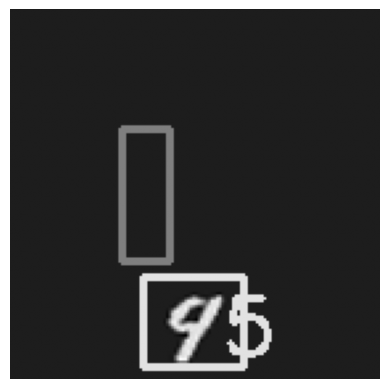

57 63 55 82 tensor(5) tensor(1)
30 23 21 25
*****


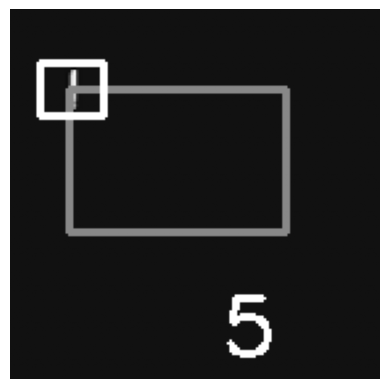

69 57 89 41 tensor(1) tensor(4)
102 56 43 43
*****


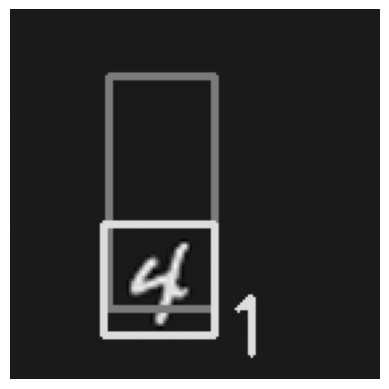

31 75 88 44 tensor(9) tensor(7)
73 91 48 44
*****


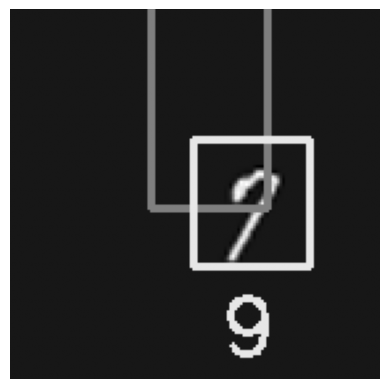

In [ ]:
# !!!
def sigmoid(x):
    return 1./(1. + np.exp(-x))

font        = cv2.FONT_HERSHEY_SIMPLEX
fontScale   = 1
fontColor   = (255,0,0)
lineType    = 2

for i, (data, target) in enumerate(dataloader):
    o = model(data)

    for t in range(5):
      out = tensor_to_image(data[t,0]).numpy() * 255

      [cx, cy, w, h] = torch.sigmoid(o["pos"][t]).detach().cpu().numpy()
      cx, cy, w, h = int(cx*140), int(cy*140), int(w*140), int(h*140)
      # cx, cy, w, h = int(sigmoid(cx)*140), int(sigmoid(cy)*140), int(sigmoid(w)*140), int(sigmoid(h)*140)

      c = o["cls"][t].detach().cpu().argmax()
      l = target[t,4:].detach().cpu().argmax()
      print(cx, cy, w, h, c, l)

      cv2.rectangle(out, (int(cy-h//2), int(cx-w//2)), (int(cy+h//2), int(cx+w//2)), 127, 2)

      [cx, cy, w, h] = target[t,:4]
      cx, cy, w, h = int(cx*140), int(cy*140), int(w*140), int(h*140)
      cv2.rectangle(out, (cy-h//2, cx-w//2), (cy+h//2, cx+w//2), 255, 2)
      print(cx, cy, w, h)
      print("*"*5)

      cv2.putText(out, str(c.item()),
                  (80, 130),
                  font,
                  fontScale,
                  fontColor,
                  lineType)

      plt.axis('off')
      plt.imshow(out,cmap='gray')
      plt.show()

    break

## Note
- Multiple bbox candidates prediction
- Non-Maximal Suppression (NMS)
  - IoU
- Highly Imbalance
- Hard Negative Training

## Next
- YOLO : CNN backbone + prediction heads
- R-CNN, Faster R-CNN : CNN backbone + region proposal + ROI Pooling + classification
- DETR : CNN backbone + Transformer (encoder + decoder), **no NMS**


# GAN

In [ ]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST

img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

batch_size = 32 # Further reduced batch size to mitigate potential OOM errors

train_dataset = MNIST(root='./data/MNIST', download=True, train=True, transform=img_transform)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = MNIST(root='./data/MNIST', download=True, train=False, transform=img_transform)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torchvision.utils

def to_img(x):
    x = 0.5 * (x + 1)
    x = x.clamp(0, 1)
    return x

In [ ]:
x,y = train_dataset[0]
x.shape, x.min(), x.max()

(torch.Size([1, 28, 28]), tensor(-1.), tensor(1.))

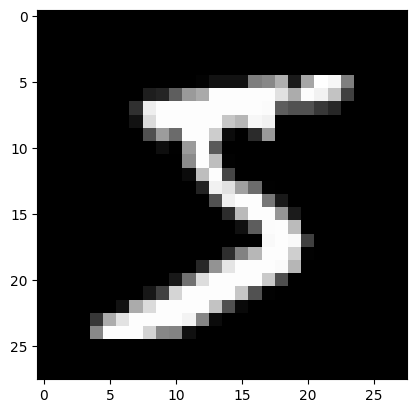

In [ ]:
plt.imshow(to_img(x[0]), cmap="gray")

In [ ]:
x[0].min(), x[0].max()

(tensor(-1.), tensor(1.))

## Exercise
- Write Generator and Discriminator classes based on input_dim=100
- Train them until the Generator can generate quite realistic images

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.functional as F

class Generator(nn.Module):
    def __init__(self, input_dim=100):
        super(Generator, self).__init__()

        self.proj = nn.Linear(input_dim, 7*7*256)
        self.conv1 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, input): # (B, input_dim)

        x = self.proj(input)
        x = x.view((-1, 256, 7, 7)) # (B, 256, 7, 7)
        x = F.interpolate(F.relu(self.conv1(x)), scale_factor=2.0) # (B, 128, 14, 14)
        x = F.interpolate(F.relu(self.conv2(x)), scale_factor=2.0) # (B, 64, 28, 28)
        x = F.tanh(self.conv3(x)) # (B, 1, 28, 28)
        return x


In [ ]:
gen = Generator(input_dim=100)

a = torch.randn(3,100)
x = gen(a)

x.shape

torch.Size([3, 1, 28, 28])

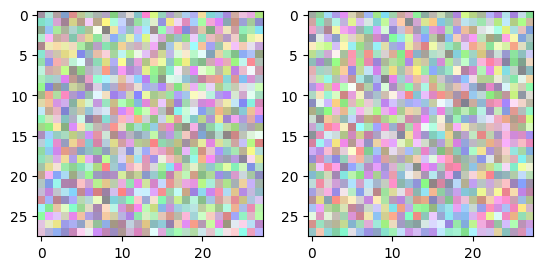

In [ ]:
x = torch.rand(3, 3, 28, 28)

fig,ax = plt.subplots(1, 2)

ax[0].imshow(to_img(x[0].view(28,28,3)))
ax[1].imshow(to_img(x[0].permute(1,2,0)))

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.fc = nn.Linear(7*7*256, 1)

    def forward(self, x0):
        x1 = F.max_pool2d(F.leaky_relu(self.conv1(x0), 0.2), kernel_size=2) # -> 14, 64
        x2 = F.max_pool2d(F.leaky_relu(self.conv2(x0), 0.2), kernel_size=2) # -> 14, 64

        x = torch.concat((x1, x2), dim=1) # -> 14, 128

        x = F.max_pool2d(F.leaky_relu(self.conv3(x), 0.2), kernel_size=2) # -> 7, 256
        x = x.view(-1, 7*7*256)
        x = self.fc(x)

        return x


In [ ]:
discriminator = Discriminator()

y = discriminator(x)
y.shape

torch.Size([3, 1])

In [ ]:
generator = Generator()
discriminator = Discriminator()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
generator = generator.to(device)
discriminator = discriminator.to(device)

learning_rate = 1e-5

gen_optimizer  = torch.optim.Adam(params=generator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
disc_optimizer = torch.optim.Adam(params=discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))

In [ ]:
generator.train()
discriminator.train()

gen_loss_avg = []
disc_loss_avg = []

num_epochs = 100

print('Training ...')
for epoch in range(num_epochs):

    print(f"Epoch {epoch+1}/{num_epochs}")

    gen_loss_avg.append(0)
    disc_loss_avg.append(0)
    num_batches = 0

    for image_batch,label_batch in train_dataloader:

        # get dataset image and create real and fake labels for use in the loss
        image_batch = image_batch.to(device)
        batch_size = image_batch.size(0)
        label_real = torch.ones(batch_size, device=device)  # half is real
        label_fake = torch.zeros(batch_size, device=device) # half is fake

        # generate a batch of images from samples of the latent prior
        latent = torch.randn(batch_size, 100, device=device)
        fake_image_batch = generator(latent)


        # train discriminator to correctly classify real and fake
        # "detach" the computation graph of the generator and the discriminator,
        # so that gradients are not backpropagated into the generator
        real_pred = discriminator(image_batch).squeeze()
        fake_pred = discriminator(fake_image_batch.detach()).squeeze() # !!!!!

        disc_loss = 0.5 * (
            F.binary_cross_entropy_with_logits(real_pred, label_real) +
            F.binary_cross_entropy_with_logits(fake_pred, label_fake))

        disc_optimizer.zero_grad()
        disc_loss.backward()
        disc_optimizer.step()

        # train generator to output an image that is classified as real
        fake_pred = discriminator(fake_image_batch).squeeze()
        gen_loss = F.binary_cross_entropy_with_logits(fake_pred, label_real)

        gen_optimizer.zero_grad()
        gen_loss.backward()
        gen_optimizer.step()

        gen_loss_avg[-1] += gen_loss.item()
        disc_loss_avg[-1] += disc_loss.item()
        num_batches += 1


    if (epoch+1) % 10 == 0:
      for i in range(6):
          plt.subplot(2,3,i+1)
          plt.tight_layout()
          plt.imshow(to_img(fake_image_batch[i][0].detach().cpu()), cmap='gray', interpolation='none')
          plt.xticks([])
          plt.yticks([])
      plt.show()

    gen_loss_avg[-1] /= num_batches
    disc_loss_avg[-1] /= num_batches
    print('Epoch [%d / %d] average loss generator vs. discrim.: %f vs. %f' %
          (epoch+1, num_epochs, gen_loss_avg[-1], disc_loss_avg[-1]))

Training ...
Epoch 1/100
Epoch [1 / 100] average loss generator vs. discrim.: 3.873098 vs. 0.100403
Epoch 2/100
Epoch [2 / 100] average loss generator vs. discrim.: 1.973897 vs. 0.310314
Epoch 3/100
Epoch [3 / 100] average loss generator vs. discrim.: 1.984413 vs. 0.278745
Epoch 4/100
Epoch [4 / 100] average loss generator vs. discrim.: 1.553278 vs. 0.398437
Epoch 5/100


KeyboardInterrupt: 

## Exercise: Conditional GAN
- Write Generator that takes as input a random vector of dimension input_dim and target class and generates image of that class
- Write Discriminator that outputs 10 nodes. If the input is fake image, then target output is 0 for all nodes. Otherwise, the target class output should be 1.
- Train them until the Generator can generate quite realistic images

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.functional as F

class Generator(nn.Module):
    def __init__(self, input_dim=100, num_classes=10):
        super(Generator, self).__init__()

        self.proj  = nn.Linear(input_dim+num_classes, 7*7*256)
        self.conv1 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, input, target): # (B, input_dim), (B,)

        one_hot = F.one_hot(target, num_classes=10)
        x = torch.concat((input, one_hot), dim=1)

        x = self.proj(x)
        x = x.view((-1, 256, 7, 7)) # (B, 256, 7, 7)
        x = F.interpolate(F.relu(self.conv1(x)), scale_factor=2.0) # (B, 128, 14, 14)
        x = F.interpolate(F.relu(self.conv2(x)), scale_factor=2.0) # (B, 64, 28, 28)
        x = F.tanh(self.conv3(x)) # (B, 1, 28, 28)
        return x

class Discriminator(nn.Module):
    def __init__(self, num_classes=10):
        super(Discriminator, self).__init__()

        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.fc = nn.Linear(7*7*256, num_classes)

    def forward(self, x):
        x = F.max_pool2d(F.leaky_relu(self.conv1(x), 0.2), kernel_size=2) # -> 14
        x = F.max_pool2d(F.leaky_relu(self.conv2(x), 0.2), kernel_size=2) # -> 7
        x = F.leaky_relu(self.conv3(x), 0.2)
        x = x.view(-1, 7*7*256)
        x = self.fc(x)

        return x


In [ ]:
generator = Generator(input_dim=100)
discriminator = Discriminator()

generator.to(device)
discriminator.to(device)

Discriminator(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc): Linear(in_features=12544, out_features=10, bias=True)
)

In [ ]:
for image_batch,label_batch in train_dataloader:

  image_batch = image_batch.to(device)
  label_batch = label_batch.to(device)

  batch_size = image_batch.size(0)

  label_fake = torch.zeros(batch_size, device=device) # half is fake

  # generate a batch of images from samples of the latent prior
  latent = torch.randn(batch_size, 100, device=device)
  fake_image_batch = generator(latent, label_batch)

  print(fake_image_batch.shape)
  print(label_batch.shape)

  real_pred = discriminator(image_batch).squeeze()
  fake_pred = discriminator(fake_image_batch.detach()).squeeze() # !!!!!

  print(real_pred.shape)
  print(fake_pred.shape)

  break

torch.Size([32, 1, 28, 28])
torch.Size([32])
torch.Size([32, 10])
torch.Size([32, 10])


In [ ]:
generator.train()
discriminator.train()

gen_loss_avg = []
disc_loss_avg = []

num_epochs = 100

print('Training ...')
for epoch in range(num_epochs):

    print(f"Epoch {epoch+1}/{num_epochs}")

    gen_loss_avg.append(0)
    disc_loss_avg.append(0)
    num_batches = 0

    for image_batch,label_batch in train_dataloader:

        image_batch = image_batch.to(device)
        label_batch = label_batch.to(device).long()

        batch_size = image_batch.size(0)

        label_fake = torch.zeros(batch_size, device=device).long() # half is fake

        # generate a batch of images from samples of the latent prior
        latent = torch.randn(batch_size, 100, device=device)
        fake_image_batch = generator(latent, label_batch)

        print(fake_image_batch.shape)
        print(label_batch.shape)

        real_pred = discriminator(image_batch).squeeze()
        fake_pred = discriminator(fake_image_batch.detach()).squeeze() # !!!!!

        print(real_pred.shape, label_batch.shape)
        disc_loss = 0.5 * (
            F.mse_loss(real_pred, F.one_hot(label_batch, num_classes=10)) +
            F.mse_loss(fake_pred, F.one_hot(label_fake, num_classes=10)))
            # F.binary_cross_entropy_with_logits(real_pred, label_real) +
            # F.binary_cross_entropy_with_logits(fake_pred, label_fake))

        disc_optimizer.zero_grad()
        disc_loss.backward()
        disc_optimizer.step()

        # train generator to output an image that is classified as real
        fake_pred = discriminator(fake_image_batch).squeeze()
        gen_loss = F.mse_loss(face_pred, F.one_hot(label_batch, num_classes=10))
        # F.binary_cross_entropy_with_logits(fake_pred, label_batch)

        gen_optimizer.zero_grad()
        gen_loss.backward()
        gen_optimizer.step()

        gen_loss_avg[-1] += gen_loss.item()
        disc_loss_avg[-1] += disc_loss.item()
        num_batches += 1


    if (epoch+1) % 10 == 0:
      for i in range(6):
          plt.subplot(2,3,i+1)
          plt.tight_layout()
          plt.imshow(to_img(fake_image_batch[i][0].detach().cpu()), cmap='gray', interpolation='none')
          plt.xticks([])
          plt.yticks([])
      plt.show()

    gen_loss_avg[-1] /= num_batches
    disc_loss_avg[-1] /= num_batches
    print('Epoch [%d / %d] average loss generator vs. discrim.: %f vs. %f' %
          (epoch+1, num_epochs, gen_loss_avg[-1], disc_loss_avg[-1]))

Training ...
Epoch 1/100
torch.Size([32, 1, 28, 28])
torch.Size([32])
torch.Size([32, 10]) torch.Size([32])


RuntimeError: Found dtype Long but expected Float

# Text classification

## Custom model

In [ ]:
from datasets import load_dataset

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
dataset = load_dataset('wisesight_sentiment') # Labels: {"pos": 0, "neu": 1, "neg": 2, "q": 3}
dataset

DatasetDict({
    train: Dataset({
        features: ['texts', 'category'],
        num_rows: 21628
    })
    validation: Dataset({
        features: ['texts', 'category'],
        num_rows: 2404
    })
    test: Dataset({
        features: ['texts', 'category'],
        num_rows: 2671
    })
})

In [ ]:
dataset["train"][0]['texts']

'ไปจองมาแล้วนาจา Mitsubishi Attrage ได้หลังสงกรานต์เลย รอขับอยู่นาจา กระทัดรัด เหมาะกับสาวๆขับรถคนเดียวแบบเรา ราคาสบายกระเป๋า ประหยัดน้ำมัน วิ่งไกลแค่ไหนหายห่วงค่ะ'

In [ ]:
class MyDataset(Dataset):

    def __init__(self, tokenizer, max_length=128, split="train"):
        self.dataset = load_dataset('wisesight_sentiment', split=split)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        tok = self.tokenizer(
            self.dataset[idx]["texts"],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt")

        return {
            "input_ids": tok["input_ids"][0],
            "label": self.dataset[idx]["category"]
        }

In [ ]:
class MyModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        dmodel):

        super(MyModel, self).__init__()

        self.dmodel = dmodel
        self.emb  = nn.Embedding(vocab_size, dmodel)

        self.lstm = nn.LSTM(dmodel, dmodel, 3, batch_first=True, bidirectional=True)

        self.fc = nn.Linear(2*dmodel, 4)


    def forward(self, x): # (B, len)

        x = self.emb(x)
        x, (h_n,c_n) = self.lstm(x)
        print(x.shape)
        print(h_n.shape)
        print(c_n.shape)
        # y = self.fc(c_n[-1])
        y = self.fc(x.mean(dim=1))

        return F.log_softmax(y, dim=1)


In [ ]:
model = MyModel(10, 128)

x = torch.randint(0, 10, (5, 10))
y = model(x)

# print(x)
print(y.shape)

torch.Size([5, 10, 256])
torch.Size([6, 5, 128])
torch.Size([6, 5, 128])
torch.Size([5, 4])


In [ ]:
from transformers import CamembertTokenizer

tokenizer = CamembertTokenizer.from_pretrained(
    "airesearch/wangchanberta-base-att-spm-uncased",
    use_fast=False,
    legacy=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MyModel( len(tokenizer), dmodel=8 ).to(device)

train_dataset = MyDataset(tokenizer, split="train")
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataset = MyDataset(tokenizer, split="validation")
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

best_acc = 0
for epoch in range(5):

  # train
  model.train()
  for t,batch in enumerate(train_dataloader):
      optimizer.zero_grad()

      out = model(batch["input_ids"].long().to(device))
      loss = F.nll_loss(out, batch["label"].to(device))

      loss.backward()
      optimizer.step()
      if (t+1)%100==0:
        print(".", end="", flush=True)


  # eval
  model.eval()
  val_loss, val_acc = 0, 0
  for t,batch in enumerate(val_dataloader):
      out = model(batch["input_ids"].long().to(device))
      loss = F.nll_loss(out, batch["label"].to(device))
      val_loss += loss
      val_acc += (out.cpu().argmax(dim=1)==batch["label"]).sum().item()

  val_loss /= len(val_dataloader)
  val_acc /= len(val_dataset)

  if val_acc > best_acc:
    print(f"Val ACC improved from {best_acc:.3f} to {val_acc:.3f}. Save model!!")
    best_acc = val_acc
    torch.save({
        "model_state": model.state_dict(),
        "acc": val_acc,
        "loss": val_loss,
        xxxx

        }, "best.pt")


torch.Size([64, 128, 16])
torch.Size([6, 64, 8])
torch.Size([6, 64, 8])
torch.Size([64, 128, 16])
torch.Size([6, 64, 8])
torch.Size([6, 64, 8])
torch.Size([64, 128, 16])
torch.Size([6, 64, 8])
torch.Size([6, 64, 8])
torch.Size([64, 128, 16])
torch.Size([6, 64, 8])
torch.Size([6, 64, 8])
torch.Size([64, 128, 16])
torch.Size([6, 64, 8])
torch.Size([6, 64, 8])
torch.Size([64, 128, 16])
torch.Size([6, 64, 8])
torch.Size([6, 64, 8])
torch.Size([64, 128, 16])
torch.Size([6, 64, 8])
torch.Size([6, 64, 8])
torch.Size([64, 128, 16])
torch.Size([6, 64, 8])
torch.Size([6, 64, 8])
torch.Size([64, 128, 16])
torch.Size([6, 64, 8])
torch.Size([6, 64, 8])
torch.Size([64, 128, 16])
torch.Size([6, 64, 8])
torch.Size([6, 64, 8])
torch.Size([64, 128, 16])
torch.Size([6, 64, 8])
torch.Size([6, 64, 8])
torch.Size([64, 128, 16])
torch.Size([6, 64, 8])
torch.Size([6, 64, 8])
torch.Size([64, 128, 16])
torch.Size([6, 64, 8])
torch.Size([6, 64, 8])
torch.Size([64, 128, 16])
torch.Size([6, 64, 8])
torch.Size([6, 

KeyboardInterrupt: 

### Exercise
Build a model from scratch with LSTM that get >60% accuracy on test split

## Fine-tune using HF framework

In [ ]:
!pip install -qU transformers datasets sentencepiece pythainlp accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.8 MB/s eta 0:00:00


In [ ]:
# define performance metrics

from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)

    return {"accuracy": acc, "f1": f1}

In [ ]:
from transformers import TrainingArguments, Trainer

batch_size = 16
logging_steps = len(dataset["train"]) // batch_size
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    disable_tqdm=False,
    logging_steps=logging_steps,
    log_level="error",
    report_to="none",
    load_best_model_at_end=True,
)

In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "airesearch/wangchanberta-base-att-spm-uncased",
    num_labels=4,
    problem_type="single_label_classification" # "multi_label_classification"
)

In [ ]:
from transformers import CamembertTokenizer

tokenizer = CamembertTokenizer.from_pretrained(
    "airesearch/wangchanberta-base-att-spm-uncased",
    use_fast=False,
    legacy=True)

In [ ]:
def tokenize(batch):
  return tokenizer(batch["texts"], max_length=128, padding="max_length", truncation=True, return_tensors="pt")

In [ ]:
dataset_tokenized = dataset.map(tokenize, batched=True, batch_size=50)

In [ ]:
dataset_tokenized = dataset_tokenized.rename_column("category", "label")
dataset_tokenized

In [ ]:
trainer = Trainer(
    model=model,
    train_dataset=dataset_tokenized["train"],
    eval_dataset=dataset_tokenized["test"],
    args=training_args,
    compute_metrics=compute_metrics,
    )

In [ ]:
trainer.train()

## LoRA model

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
      lora_alpha=16,
      lora_dropout=0.1,
      r=64,
      bias="none",
      task_type="SEQ_CLS", # Change task_type to "SEQ_CLS"
      target_modules=[
          "query", "key", "value", "dense"
          ],
)

# Wrap the model with PEFT
peft_model = get_peft_model(model, lora_config)

# Print the number of trainable parameters
peft_model.print_trainable_parameters()

In [ ]:
trainer = Trainer(
    model=peft_model,
    train_dataset=dataset_tokenized["train"],
    eval_dataset=dataset_tokenized["test"],
    args=training_args,
    compute_metrics=compute_metrics,
    )

In [ ]:
trainer.train()


## Query LLM via Ollama

In [ ]:
!apt-get install zstd
!curl -fsSL https://ollama.com/install.sh | sh

In [ ]:
import subprocess

subprocess.Popen(["ollama", "serve"])

In [ ]:
!curl http://localhost:11434 # -> should say "Ollama is running"

In [ ]:
!ollama pull gemma4:e2b
!ollama list

In [ ]:
!pip install -qU ollama
!pip install -qU langchain-ollama

In [ ]:
from langchain_core.prompts import PromptTemplate

# Define a prompt template
system_prompt = (
    """
    You are an expert in Thai NLP.
    Your job is to classify an input text as being either positive (class 0), neutral (class 1), negative (class 2), or question (class 3).
    You must only answer the class index without explanation.
    """
)  # System prompt

prompt_template = PromptTemplate(
    template=f"{system_prompt}\n\nInput: {{input}}\nAnswer:"
)

In [ ]:
from langchain_ollama import OllamaLLM

llm = OllamaLLM(model="gemma4:e2b")

In [ ]:
chain = prompt_template | llm

In [ ]:
response = chain.invoke({"input": dataset["train"][0]["texts"]})

print(response)